# UFES Dataset Analysis

## Imports

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Reading the Data

In [24]:
CSV_PATH = "metadata.csv"
df = pd.read_csv(CSV_PATH)
df.head()

,patient_id,lesion_id,smoke,drink,background_father,background_mother,age,pesticide,gender,skin_cancer_history,...,diameter_2,diagnostic,itch,grew,hurt,changed,bleed,elevation,img_id,biopsed
0,PAT_1516,1765,NaN,NaN,NaN,NaN,8,NaN,NaN,NaN,...,NaN,NEV,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,PAT_1516_1765_530.png,False
1,PAT_46,881,False,False,POMERANIA,POMERANIA,55,False,FEMALE,True,...,5.0,BCC,TRUE,TRUE,FALSE,TRUE,TRUE,TRUE,PAT_46_881_939.png,True
2,PAT_1545,1867,NaN,NaN,NaN,NaN,77,NaN,NaN,NaN,...,NaN,ACK,TRUE,FALSE,FALSE,FALSE,FALSE,FALSE,PAT_1545_1867_547.png,False
3,PAT_1989,4061,NaN,NaN,NaN,NaN,75,NaN,NaN,NaN,...,NaN,ACK,TRUE,FALSE,FALSE,FALSE,FALSE,FALSE,PAT_1989_4061_934.png,False
4,PAT_684,1302,False,True,POMERANIA,POMERANIA,79,False,MALE,True,...,5.0,BCC,TRUE,TRUE,FALSE,FALSE,TRUE,TRUE,PAT_684_1302_588.png,True


## Shape and Columns

In [25]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (2298, 26)
Columns: ['patient_id', 'lesion_id', 'smoke', 'drink', 'background_father', 'background_mother', 'age', 'pesticide', 'gender', 'skin_cancer_history', 'cancer_history', 'has_piped_water', 'has_sewage_system', 'fitspatrick', 'region', 'diameter_1', 'diameter_2', 'diagnostic', 'itch', 'grew', 'hurt', 'changed', 'bleed', 'elevation', 'img_id', 'biopsed']


## Missing Values

In [26]:
df.isna().sum()

patient_id               0
lesion_id                0
smoke                  804
drink                  804
background_father      818
background_mother      822
age                      0
pesticide              804
gender                 804
skin_cancer_history    804
cancer_history         804
has_piped_water        804
has_sewage_system      804
fitspatrick            804
region                   0
diameter_1             804
diameter_2             804
diagnostic               0
itch                     0
grew                     0
hurt                     0
changed                  0
bleed                    0
elevation                0
img_id                   0
biopsed                  0
dtype: int64

## Diagnostic Distribution

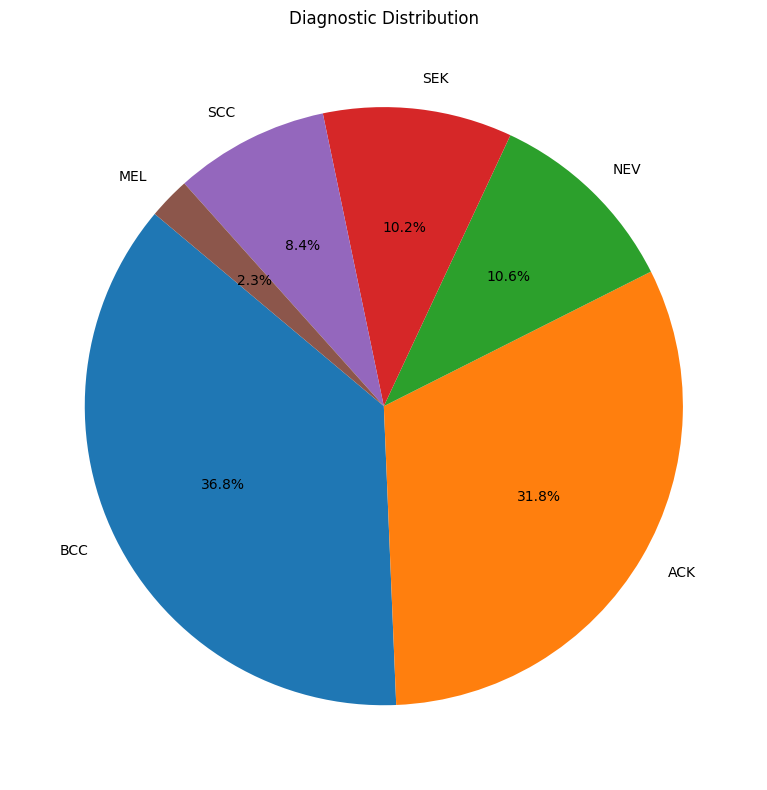

In [27]:
diagnostics = df["diagnostic"].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(
    diagnostics, 
    labels=diagnostics.index, 
    autopct="%1.1f%%", 
    startangle=140
)
plt.title("Diagnostic Distribution")
plt.tight_layout()
plt.show()

## Skin Tone Distribution

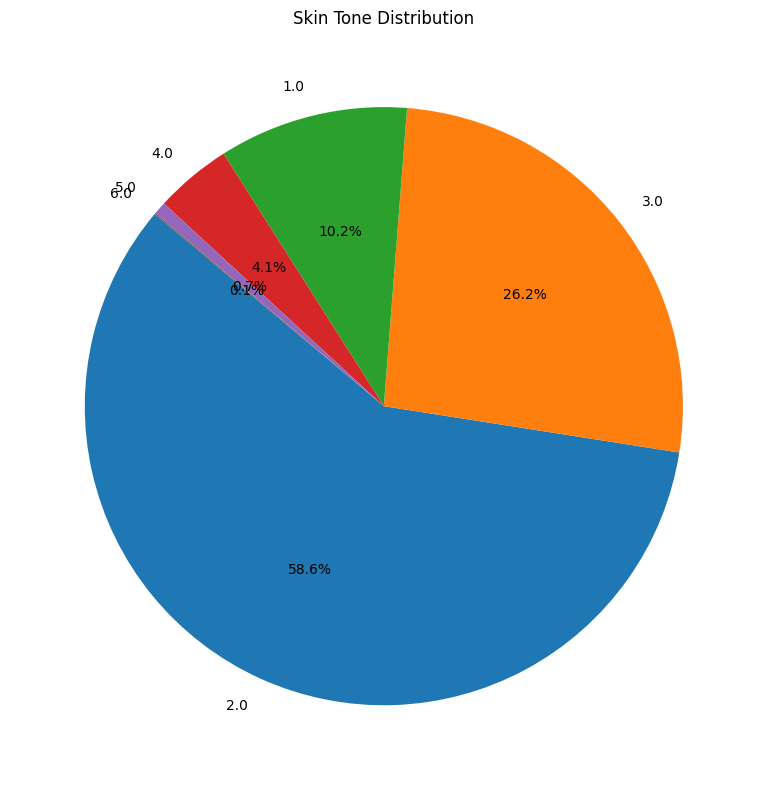

In [28]:
skin_tones = df["fitspatrick"].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(
    skin_tones, 
    labels=skin_tones.index, 
    autopct="%1.1f%%", 
    startangle=140
)
plt.title("Skin Tone Distribution")
plt.tight_layout()
plt.show()

## Cross-Tabs for Fairness / Label Mix


=== Crosstab: FST × Three-Class ===
diagnostic   ACK  BCC  MEL  NEV  SCC  SEK
fitspatrick                              
1.0           25  101    3    4   16    4
2.0          156  502   35   34  126   23
3.0           89  217   10   24   45    7
4.0           10   22    4   12    3   11
5.0            3    3    0    1    2    1
6.0            0    0    0    0    0    1


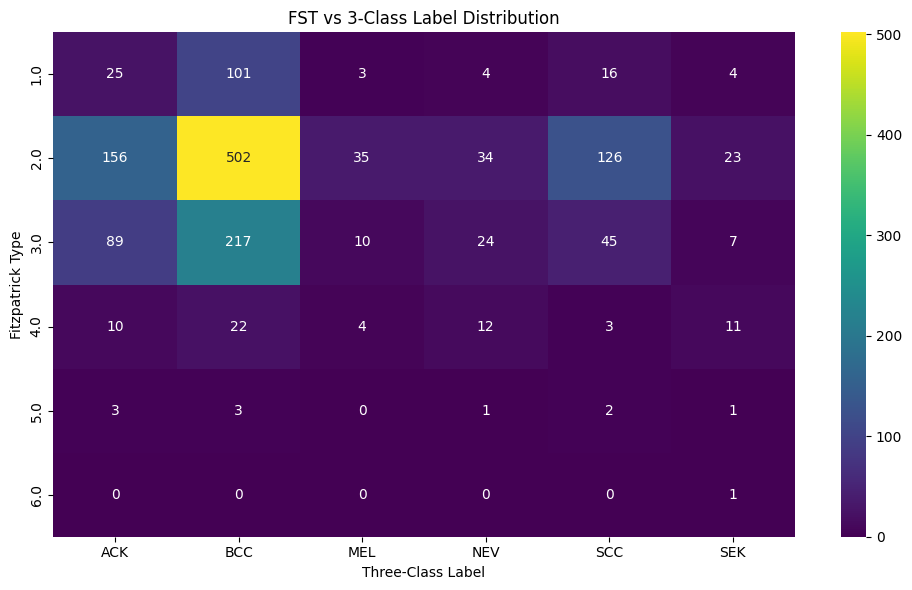

In [29]:
ct_fst_diag = pd.crosstab(df["fitspatrick"], df["diagnostic"])
print("\n=== Crosstab: FST × Three-Class ===")
print(ct_fst_diag)

plt.figure(figsize=(10, 6))
sns.heatmap(ct_fst_diag, annot=True, fmt="d", cmap="viridis")
plt.title("FST vs 3-Class Label Distribution")
plt.ylabel("Fitzpatrick Type")
plt.xlabel("Three-Class Label")
plt.tight_layout()
plt.show()